# Bank Customer Churn Prediction

## Objective
Identify customers who are likely to leave the bank.

This notebook uses a very simple and beginner friendly approach:

1. Load the dataset
2. Clean unnecessary columns
3. Convert categorical columns into numbers
4. Train a Decision Tree model
5. Check model performance
6. Understand feature importance
7. Write business insights and conclusion

## Step 1: Import Required Libraries

We use:

- `pandas` for reading and handling data
- `matplotlib` for simple charts
- `train_test_split` for splitting data
- `DecisionTreeClassifier` for classification
- `accuracy_score` and `confusion_matrix` for checking model performance

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 2: Load the Dataset

Here we read the CSV file using pandas.

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3: Basic Data Exploration

We check:

- Number of rows and columns
- Column names
- Missing values
- Basic information about the dataset

In [4]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Info:")
df.info()

Rows and Columns: (10000, 14)

Column Names:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography       

## Step 4: Understand the Target Column

The target column is `Exited`.

- `Exited = 1` means customer left the bank
- `Exited = 0` means customer stayed with the bank

In [5]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

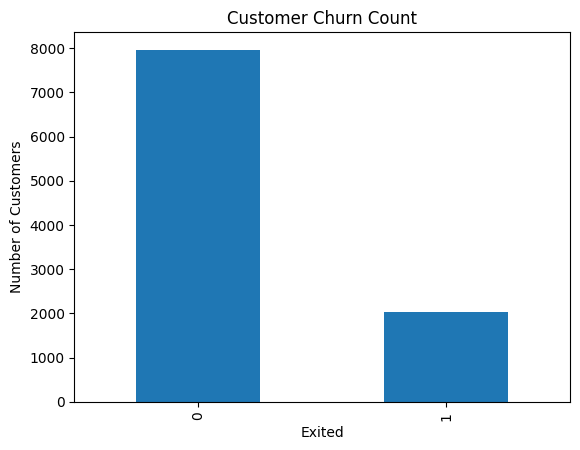

In [6]:
df["Exited"].value_counts().plot(kind="bar")

plt.title("Customer Churn Count")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

## Step 5: Simple Data Cleaning

Some columns do not help in prediction:

- `RowNumber`
- `CustomerId`
- `Surname`

These are just identifiers, so we remove them.

In [7]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 6: Explore Important Features

Now we look at simple relationships between churn and important features.

### Churn by Geography

This shows which country has more customers leaving the bank.

In [8]:
pd.crosstab(df["Geography"], df["Exited"])

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


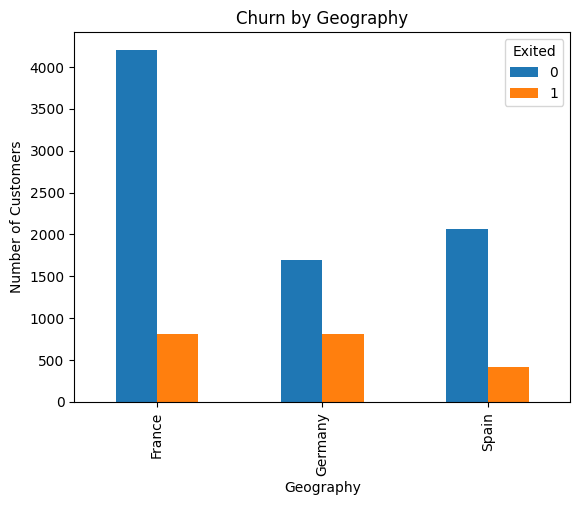

In [9]:
pd.crosstab(df["Geography"], df["Exited"]).plot(kind="bar")

plt.title("Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.show()

### Churn by Gender

This shows churn comparison between male and female customers.

In [10]:
pd.crosstab(df["Gender"], df["Exited"])

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


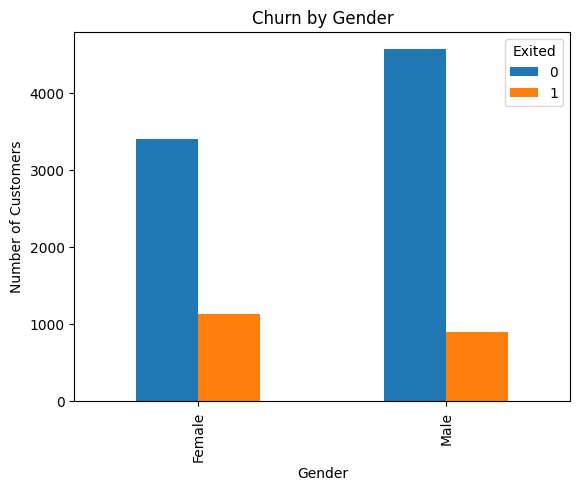

In [11]:
pd.crosstab(df["Gender"], df["Exited"]).plot(kind="bar")

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

### Churn by Age

This chart helps us see whether age has an effect on customer churn.

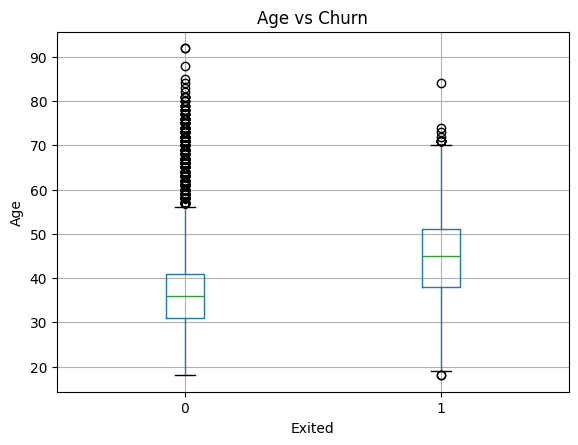

In [12]:
df.boxplot(column="Age", by="Exited")

plt.title("Age vs Churn")
plt.suptitle("")
plt.xlabel("Exited")
plt.ylabel("Age")
plt.show()

## Step 7: Encode Categorical Columns

Machine learning models need numbers, not text.

So we convert:

- `Geography`
- `Gender`

into numeric columns using `pd.get_dummies()`.

This is an easy method for one hot encoding.

In [13]:
df_encoded = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Step 8: Separate Input Features and Target

`X` contains the columns used for prediction.

`y` contains the answer we want to predict, which is `Exited`.

In [14]:
X = df_encoded.drop("Exited", axis=1)
y = df_encoded["Exited"]

print("Input columns:")
print(X.columns)

Input columns:
Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='str')


## Step 9: Split the Data

We split the dataset into:

- Training data: used to train the model
- Testing data: used to check model performance

Here, 80 percent data is used for training and 20 percent for testing.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 8000
Testing rows: 2000


## Step 10: Train a Simple Decision Tree Model

A Decision Tree is easy to understand because it makes decisions using simple rules.

We use `max_depth=4` to keep the model simple and avoid making it too complicated.

In [16]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## Step 11: Make Predictions

Now the model predicts whether customers in the test data will leave the bank.

In [17]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Step 12: Evaluate the Model

Accuracy tells us how many predictions were correct.

The confusion matrix shows:

- True positives
- True negatives
- Wrong churn predictions
- Missed churn customers

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8535


In [19]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1563   44]
 [ 249  144]]


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1607
           1       0.77      0.37      0.50       393

    accuracy                           0.85      2000
   macro avg       0.81      0.67      0.70      2000
weighted avg       0.84      0.85      0.83      2000



## Step 13: Feature Importance

Feature importance tells us which columns had the most effect on churn prediction.

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
1,Age,0.462718
4,NumOfProducts,0.340831
6,IsActiveMember,0.175870
3,Balance,0.015780
7,EstimatedSalary,0.004800
2,Tenure,0.000000
0,CreditScore,0.000000
5,HasCrCard,0.000000
8,Geography_Germany,0.000000
9,Geography_Spain,0.000000


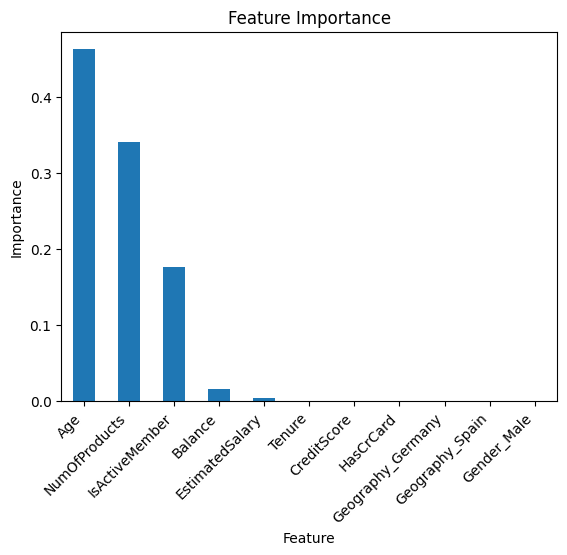

In [22]:
importance.plot(kind="bar", x="Feature", y="Importance", legend=False)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

## Step 14: Business Insights

Based on the exploration and feature importance, we can write simple business insights.

### Key Insights

1. **Age is usually an important factor**

   Older customers may show a higher chance of leaving the bank compared with younger customers.

2. **Number of products matters**

   Customers with fewer or certain numbers of bank products may behave differently. Product usage can strongly affect churn.

3. **Active membership is important**

   Customers who are not active members may have a higher chance of leaving.

4. **Geography can influence churn**

   Some countries may show higher churn than others. The bank should compare churn by geography.

5. **Balance may affect churn**

   Customers with high balances can be important to retain because losing them may hurt the bank more.

## Step 15: Conclusion

In this notebook, we built a simple customer churn prediction model.

We cleaned the dataset, encoded categorical columns like geography and gender, trained a Decision Tree classifier, and evaluated the model using accuracy, confusion matrix, and classification report.

The feature importance results help the bank understand which factors influence churn the most. Features such as age, number of products, active membership, balance, and geography can help the bank identify customers who may leave.

### Final Business Recommendation

The bank should focus on customers who:

- Are older
- Are inactive members
- Have fewer product relationships
- Belong to high churn geography groups
- Have high balances but low engagement

These customers should receive better service, retention offers, product recommendations, or personal follow up before they leave the bank.